In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./train.csv") # titanic dataset

#### Data Dictionary
| Variable | Definition | Key |
|---|---|---|
| survival | Survival | 0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex | Sex |  |
| Age | Age in years |  |
| sibsp | # of siblings / spouses aboard the Titanic |  |
| parch | # of parents / children aboard the Titanic |  |
| ticket | Ticket number |  |
| fare | Passenger fare |  |
| cabin | Cabin number |  |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

#### Variable Notes
**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
- Sibling = brother, sister, stepbrother, stepsister
- Spouse = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
- Parent = mother, father
- Child = daughter, son, stepdaughter, stepson
- Some children travelled only with a nanny, therefore parch=0 for them.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 1. Categorical Data

Categorical columns present in the Titanic Dataset
- Survived (target)
- Pclass
- Name: though categorical, but cannot be easily analyzed
- Sex
- SibSp (Siblings/Spouse): throuh numeric, but we can consider it as categories
- Parch (Parent/Child): throuh numeric, but we can consider it as categories
- Ticket: though categorical, but cannot be easily analyzed
- Cabin
Embarked

### a. Countplot

<Axes: xlabel='Survived', ylabel='count'>

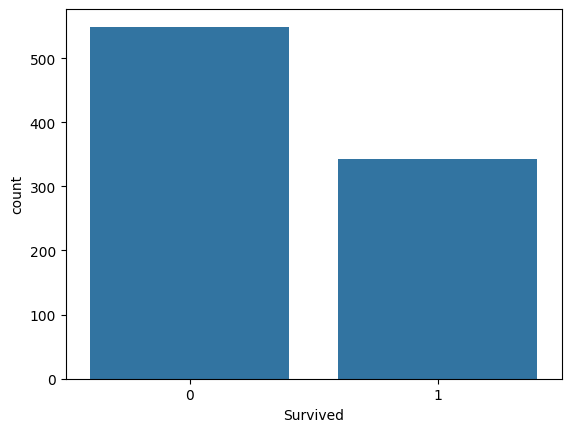

In [10]:
sns.countplot(df, x="Survived")

In [13]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

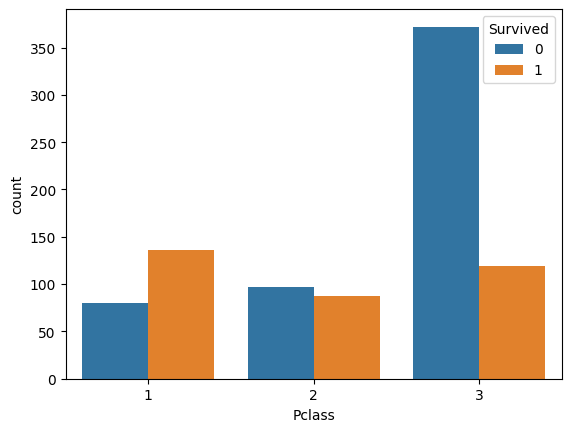

In [12]:
sns.countplot(df, x="Pclass", hue="Survived")

<Axes: xlabel='Sex', ylabel='count'>

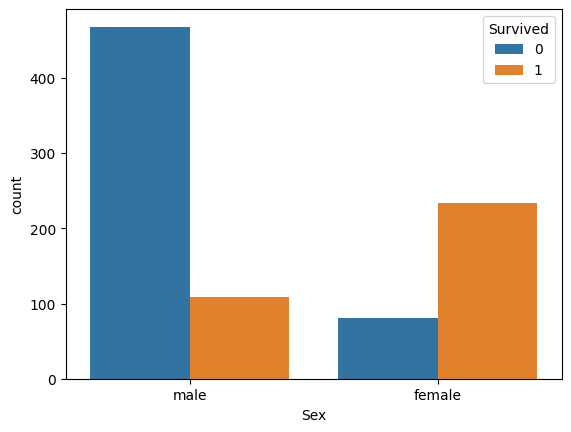

In [15]:
sns.countplot(df, x="Sex", hue="Survived")

<Axes: xlabel='Embarked', ylabel='count'>

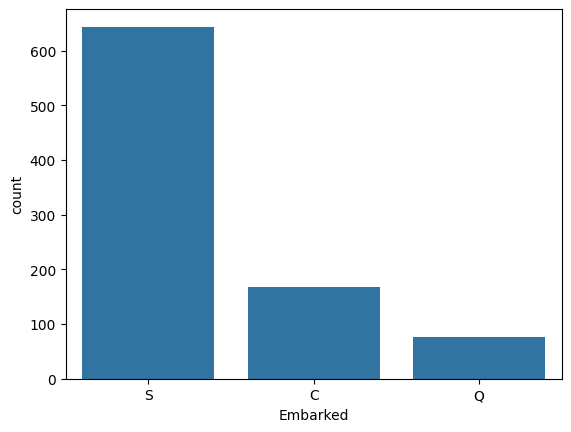

In [17]:
sns.countplot(df, x="Embarked")

### b. Piechart

<Axes: ylabel='count'>

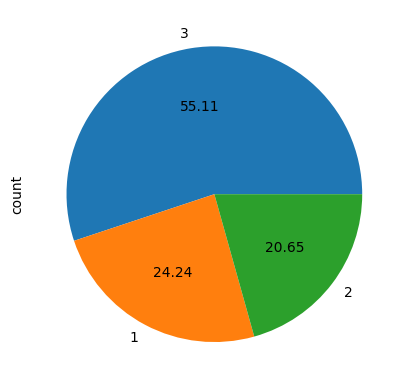

In [21]:
df["Pclass"].value_counts().plot(kind="pie", autopct="%.2f")

## 2. Numerical Data

### a. Histogram

Numerical columns present in the Titanic Dataset
- Age
- Fare

(array([ 64., 115., 230., 155.,  86.,  42.,  17.,   5.]),
 array([ 0.42  , 10.3675, 20.315 , 30.2625, 40.21  , 50.1575, 60.105 ,
        70.0525, 80.    ]),
 <BarContainer object of 8 artists>)

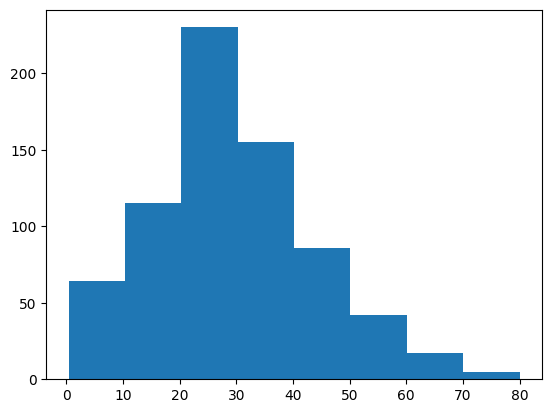

In [24]:
plt.hist(df["Age"], bins=8)

### b. Distplot

<Axes: xlabel='Age', ylabel='Probability'>

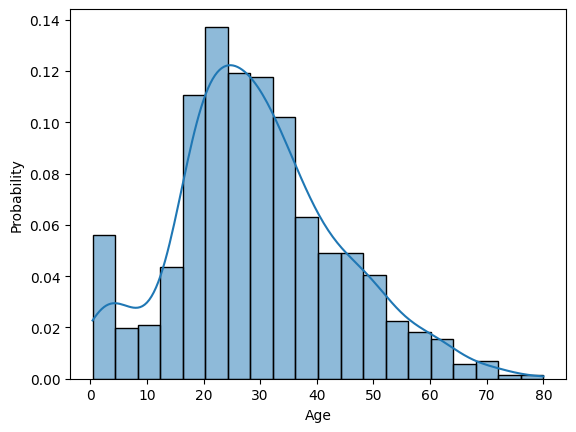

In [45]:
sns.histplot(df, x="Age", kde=True, stat="probability")

### c. Boxplot

<Axes: xlabel='Age'>

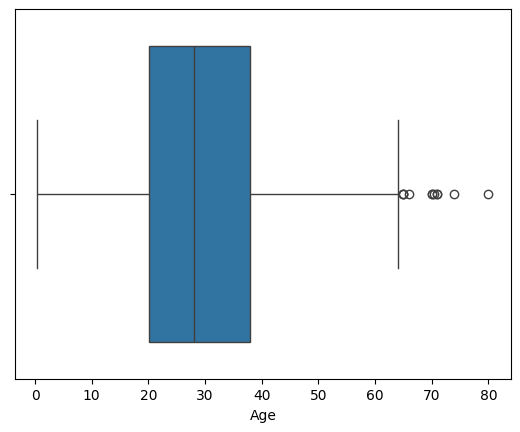

In [47]:
sns.boxplot(df, x="Age")

In [50]:
df.describe()[["Age", "Fare"]]

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [51]:
df.Age.skew()

np.float64(0.38910778230082704)